In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer 
from sklearn.preprocessing import RobustScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from datetime import datetime
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from math import pi
import matplotlib.gridspec as gridspec
import plotly.express as px
from datetime import datetime

In [2]:
df = pd.read_csv('marketing_campaign.csv', sep='\t') 

print(f"Size of Dataset: {df.shape}")
print(df.head())
print(df.info())

Size of Dataset: (2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2 

In [3]:
# Feature Engineering

current_year = 2015  # Dataset ending date is Dec 2014
df=df.rename(columns={"MntWines": "Wines",
                      "MntFruits":"Fruits",
                      "MntMeatProducts":"Meat",
                      "MntFishProducts":"Fish",
                      "MntSweetProducts":"Sweets",
                      "MntGoldProds":"Gold"
})

df=df.rename(columns={
    "NumDealsPurchases":"Deals", 
    "NumCatalogPurchases":"Catalog",
    "NumStorePurchases":"Store",
    "NumWebPurchases":"Web"
})

# Segment education levels
df['Education'] = df['Education'].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

df['Age'] = current_year - df['Year_Birth']  # Calculate age
df['Spent'] = df['Wines'] + df['Fruits'] + df['Meat'] + df['Fish'] + df['Sweets'] + df['Gold']  # Total spending
df['Children'] = df['Kidhome'] + df['Teenhome']  # Total children count

# Unify Marital_Status into Couple/Alone
df['Marital_Status'] = df['Marital_Status'].replace(['Divorced', 'Single', 'Together', 'Married', 'Widow', 'Absurd', 'YOLO'],
                                                   ['Alone', 'Alone', 'Couple', 'Couple', 'Alone', 'Alone', 'Alone'])

df['Family_Size'] = df['Children'] + df['Marital_Status'].apply(lambda x: 2 if x in ['Couple'] else 1)
df['Is_Parent'] = df['Children'].apply(lambda x: 1 if x > 0 else 0)
df['Total_Accepted_Cmp'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1)

# Handle missing values
df.dropna(inplace=True)

# Advanced Feature Engineering 

# Number of independent purchases
df['Frequency'] = df['Web'] + df['Catalog'] + df['Store']

# 1. RFM variant
df['Avg_Order_Value'] = df['Spent'] / df['Frequency']
df.loc[df['Frequency'] == 0, 'Avg_Order_Value'] = 0

# 2. Ratio Features - Purchasing power
df['Spent_per_Income'] = df['Spent'] / df['Income']
df.loc[df['Income'] == 0, 'Spent_per_Income'] = 0

df['Deals_Ratio'] = df['Deals'] / df['Frequency'] # Discount purchase ratio
df['Catalog_Ratio'] = df['Catalog'] / df['Frequency'] # Catalog purchase ratio
df['Store_Ratio'] = df['Store'] / df['Frequency'] # Store purchase ratio
df['Web_Ratio'] = df['Web'] / df['Frequency']  # Web purchase ratio
df.loc[df['Frequency'] == 0, ['Deals_Ratio', 'Catalog_Ratio', 'Store_Ratio', 'Web_Ratio']] = 0

# 3. Consumption Preference
# Define all product columns
mnt_cols = ['Wines', 'Fruits', 'Meat', 'Fish',
            'Sweets', 'Gold']

# Calculate spending percentage for each product
for col in mnt_cols:
    new_col_name = f'{col}_Pcnt'  # New column: MntWines_Pcnt, etc.

    # Calculate percentage
    df[new_col_name] = df[col] / df['Spent']

    # Handle division by zero: if Spent is 0, percentage is 0
    df.loc[df['Spent'] == 0, new_col_name] = 0

# Drop redundant features
to_drop = [
    'ID',
    'Year_Birth',
    'Dt_Customer',
    'Kidhome',
    'Teenhome',
    'Z_CostContact',
    'Z_Revenue',
]

# Get columns to drop that exist in the DataFrame
columns_to_drop = [col for col in to_drop if col in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

EDA

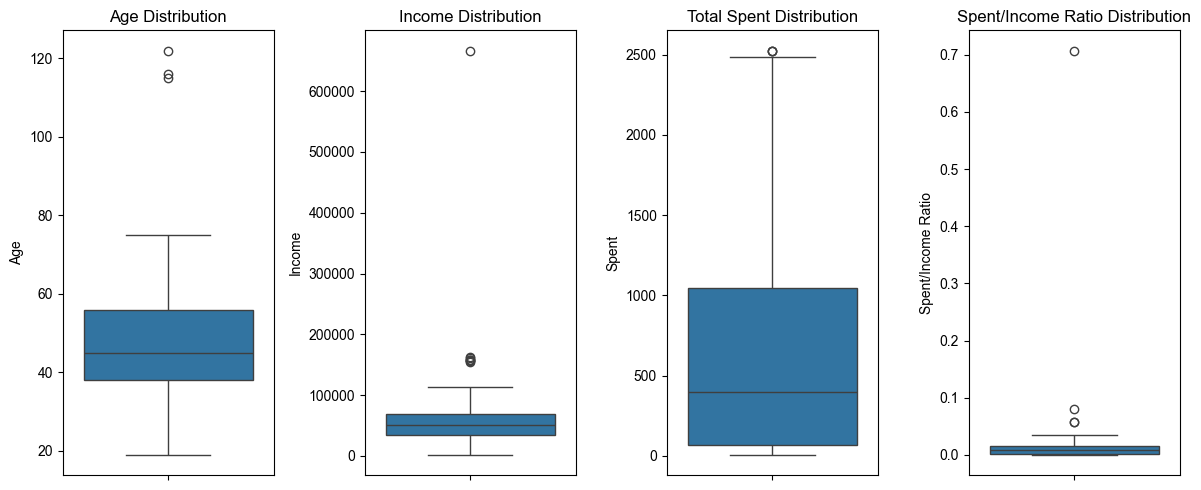

In [4]:
# Set up plotting configuration
plt.rcParams['font.sans-serif'] = ['Arial']  # Set font for compatibility (SimHei removed)
plt.rcParams['axes.unicode_minus'] = False   # Handle negative sign display

# --- Plot Boxplots for Income and Spent ---
plt.figure(figsize=(12, 5))

# Plot Income boxplot
plt.subplot(1, 4, 1)
sns.boxplot(y=df['Age'])
plt.title('Age Distribution')
plt.ylabel('Age')

# Plot Income boxplot
plt.subplot(1, 4, 2)
sns.boxplot(y=df['Income'])
plt.title('Income Distribution')
plt.ylabel('Income')

# Plot Spent boxplot
plt.subplot(1, 4, 3)
sns.boxplot(y=df['Spent'])
plt.title('Total Spent Distribution')
plt.ylabel('Spent')

# Plot Spent/Income boxplot
plt.subplot(1, 4, 4)
sns.boxplot(y=df['Spent_per_Income'])
plt.title('Spent/Income Ratio Distribution')
plt.ylabel('Spent/Income Ratio')

plt.tight_layout()
plt.show()

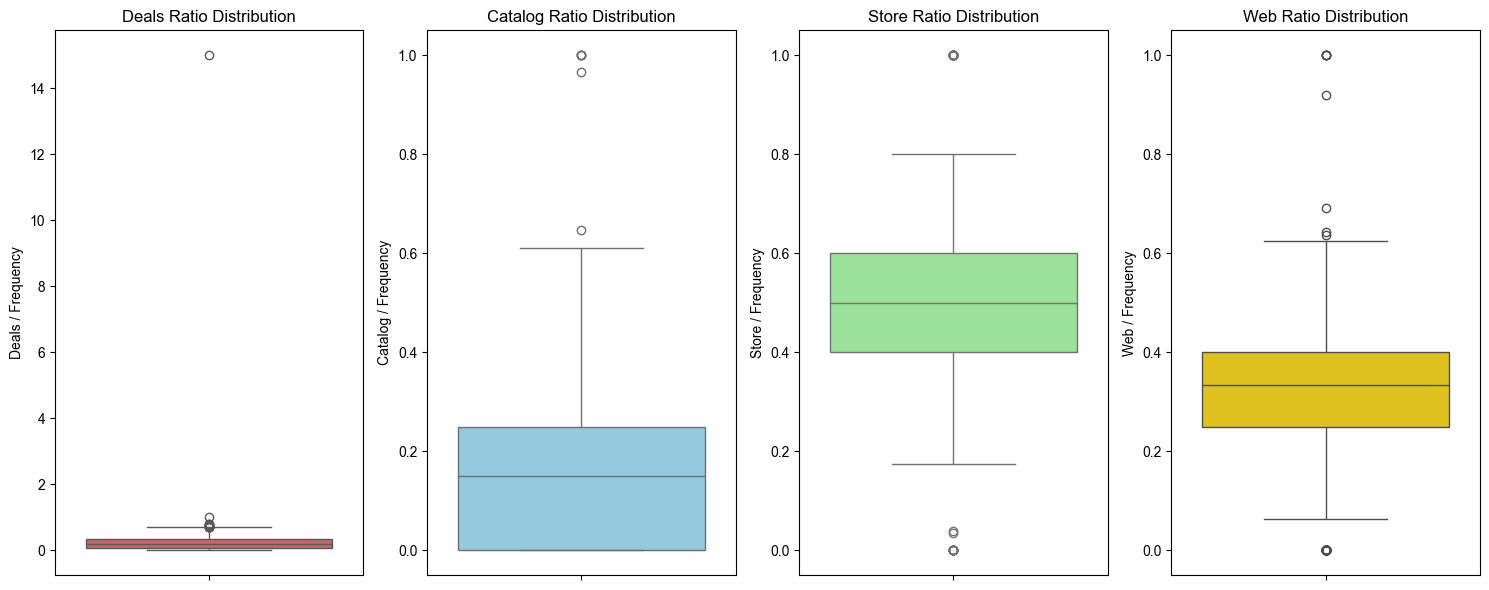

In [5]:
# --- Plot Boxplots for Channel and Deal Ratios ---
plt.figure(figsize=(15, 6))

# Plot Deals_Ratio boxplot
plt.subplot(1, 4, 1)
sns.boxplot(y=df['Deals_Ratio'], color='indianred')
plt.title('Deals Ratio Distribution')
plt.ylabel('Deals / Frequency')

# Plot Catalog_Ratio boxplot
plt.subplot(1, 4, 2)
sns.boxplot(y=df['Catalog_Ratio'], color='skyblue')
plt.title('Catalog Ratio Distribution')
plt.ylabel('Catalog / Frequency')

# Plot Store_Ratio boxplot
plt.subplot(1, 4, 3)
sns.boxplot(y=df['Store_Ratio'], color='lightgreen')
plt.title('Store Ratio Distribution')
plt.ylabel('Store / Frequency')

# Plot Web_Ratio boxplot
plt.subplot(1, 4, 4)
sns.boxplot(y=df['Web_Ratio'], color='gold')
plt.title('Web Ratio Distribution')
plt.ylabel('Web / Frequency')

plt.tight_layout()
plt.show()

In [6]:
# Filter outliers
df = df[df['Age'] <= 114]
df = df[df['Income'] <= 600000]
df = df[df['Spent_per_Income'] <= 0.7]
df = df[df['Deals_Ratio'] <= 1] # the Ratio must smaller or equal to 1
df_processed = df.copy()

# Output the final data shape
print(f"Final data shape for analysis and clustering: {df_processed.shape}")

Final data shape for analysis and clustering: (2210, 41)


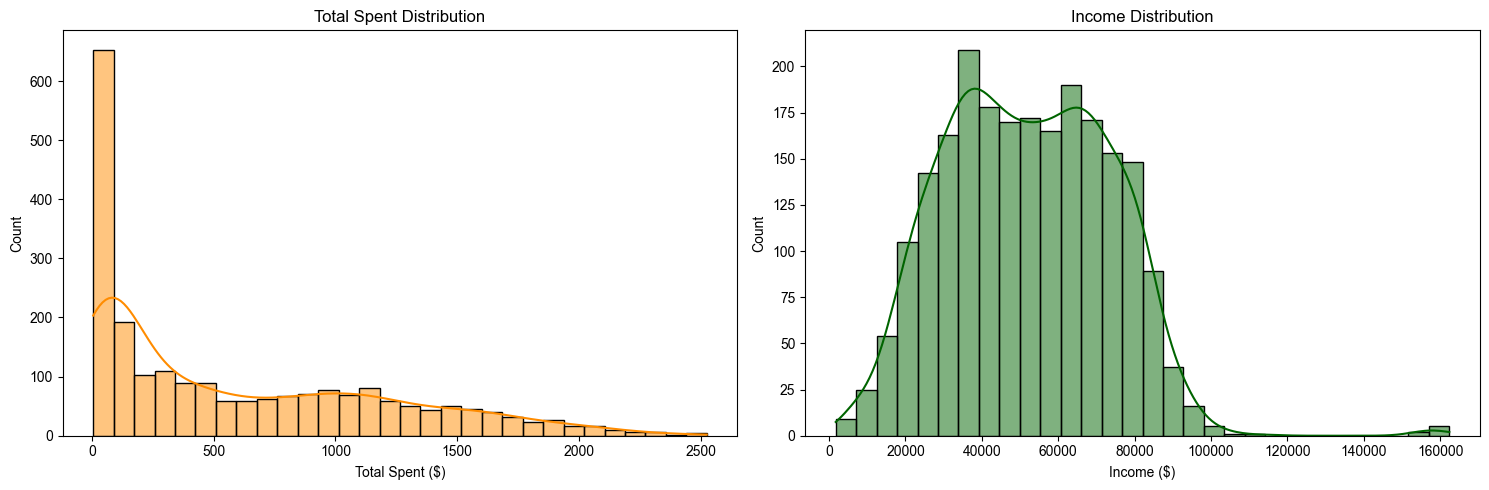

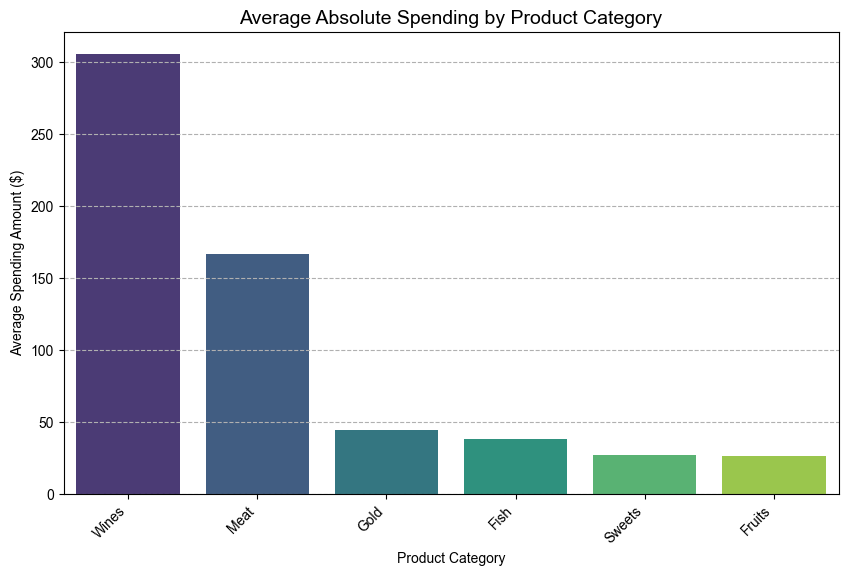

In [7]:
# ====================================================================
# A. Spending Feature Analysis
# ====================================================================

# 1. Spent and Income Distribution
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_processed['Spent'], kde=True, bins=30, color='darkorange')
plt.title('Total Spent Distribution')
plt.xlabel('Total Spent ($)')

plt.subplot(1, 2, 2)
sns.histplot(df_processed['Income'], kde=True, bins=30, color='darkgreen')
plt.title('Income Distribution')
plt.xlabel('Income ($)')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# B. Consumption Preference Structure Analysis
# ------------------------------------------------------------------

spending_cols = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

spending_mean = df_processed[spending_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=spending_mean.index,
    y=spending_mean.values, 
    palette='viridis',
    hue=spending_mean.index,
    legend=False
)

plt.title('Average Absolute Spending by Product Category', fontsize=14)
plt.ylabel('Average Spending Amount ($)')
plt.xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.show()

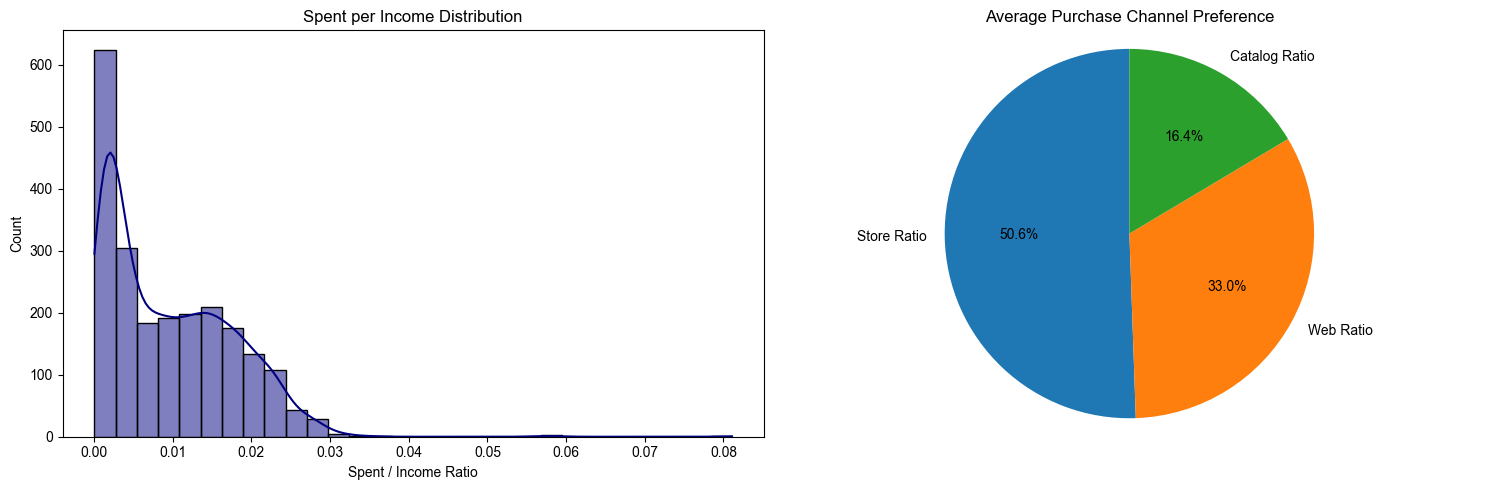

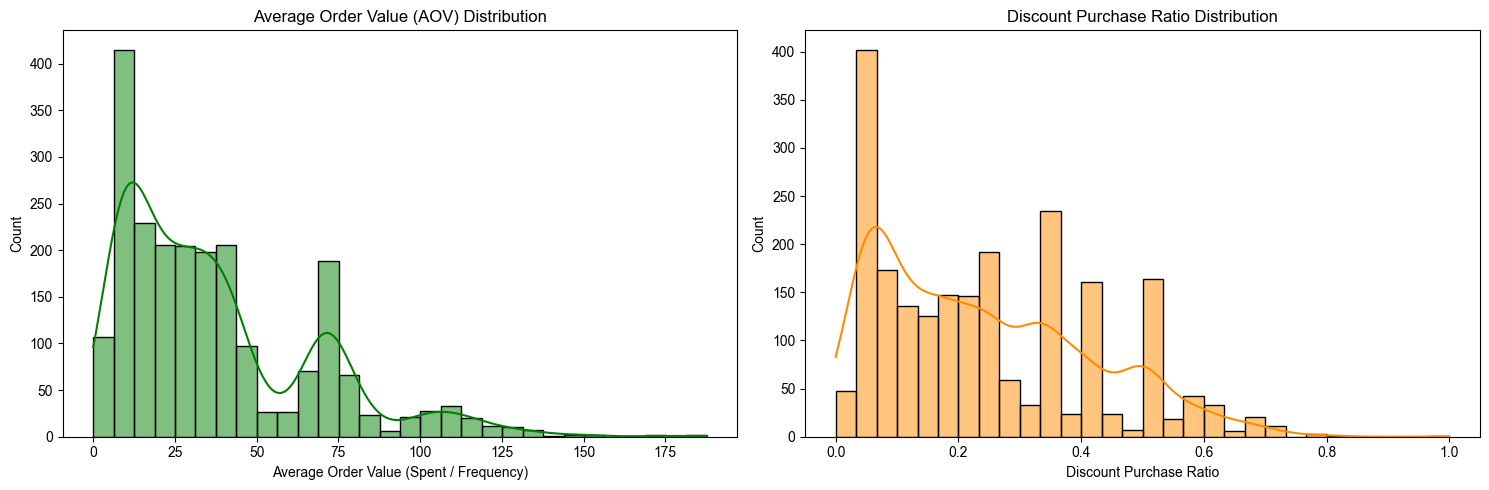

In [8]:
# ====================================================================
# B. Advanced Ratio Features Analysis (Power & Channel Preference)
# ====================================================================

# 1. Purchasing Power Ratio: Spent_per_Income
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_processed['Spent_per_Income'], kde=True, bins=30, color='navy')
plt.title('Spent per Income Distribution')
plt.xlabel('Spent / Income Ratio')

# 2. Channel Preference
plt.subplot(1, 2, 2)
channel_ratios = df_processed[['Store_Ratio', 'Web_Ratio', 'Catalog_Ratio']].mean()

pie_labels = ['Store Ratio', 'Web Ratio', 'Catalog Ratio'] 

plt.pie(
    channel_ratios.values,
    labels=pie_labels,
    autopct='%1.1f%%', 
    startangle=90, 
)

plt.title('Average Purchase Channel Preference', fontsize=12)
plt.axis('equal') 

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    df_processed['Avg_Order_Value'], 
    kde=True, 
    bins=30, 
    color='green'
)
plt.title('Average Order Value (AOV) Distribution')
plt.xlabel('Average Order Value (Spent / Frequency)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(
    df_processed['Deals_Ratio'], 
    kde=True, 
    bins=30, 
    color='darkorange'
)
plt.title('Discount Purchase Ratio Distribution')
plt.xlabel('Discount Purchase Ratio')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

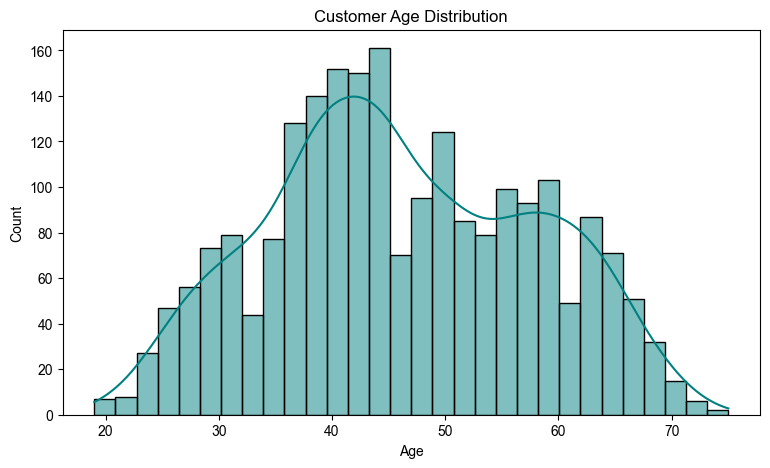

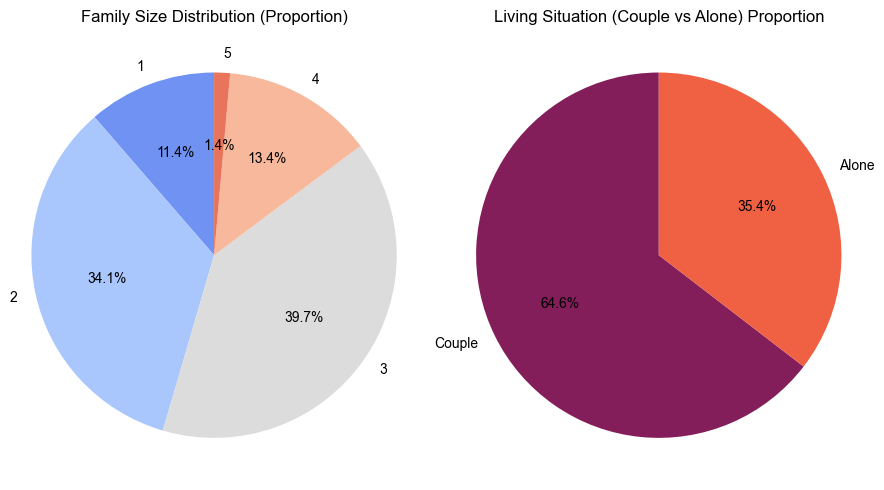

In [9]:
# ====================================================================
# C. Demographics and Family Structure Analysis
# ====================================================================
plt.figure(figsize=(9, 5))

# 1. Age Distribution
sns.histplot(df_processed['Age'], kde=True, bins=30, color='teal')
plt.title('Customer Age Distribution')

plt.figure(figsize=(9, 5))
# 2. Family Size Distribution
plt.subplot(1, 2, 1)
family_counts = df_processed['Family_Size'].value_counts().sort_index()

plt.pie(
    family_counts.values,
    labels=family_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('coolwarm', len(family_counts)) 
)
plt.title('Family Size Distribution (Proportion)')
plt.axis('equal')

# 3. Living Situation
plt.subplot(1, 2, 2)
marital_counts = df_processed['Marital_Status'].value_counts()

plt.pie(
    marital_counts.values,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('rocket', len(marital_counts))
)
plt.title('Living Situation (Couple vs Alone) Proportion')
plt.axis('equal')


plt.tight_layout()
plt.show()

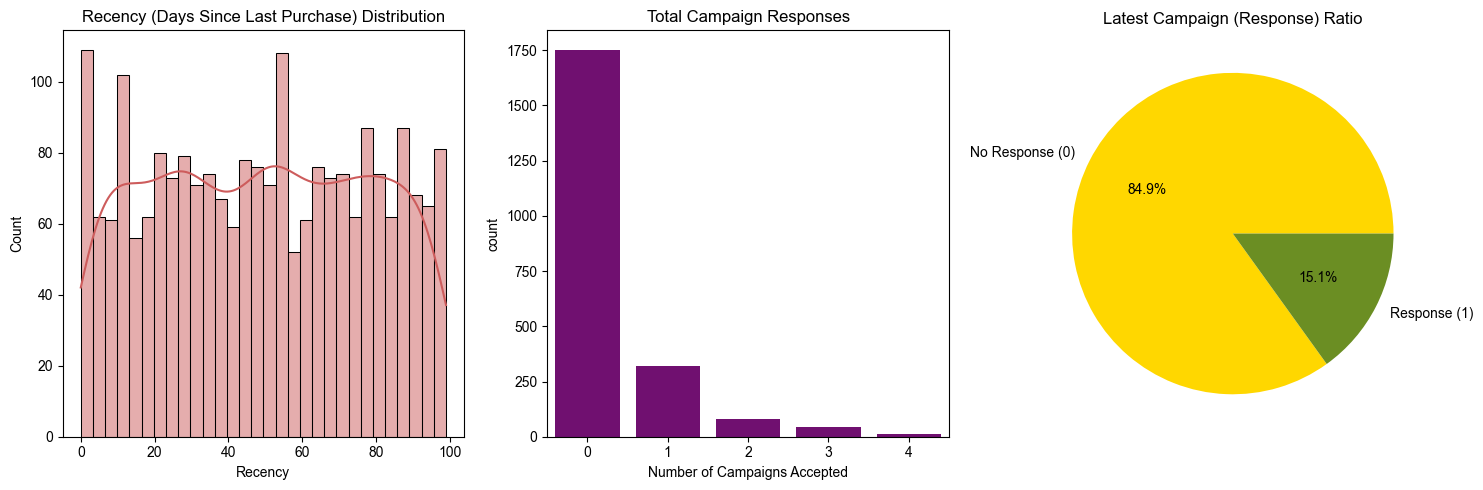

In [10]:
# ====================================================================
# D. Time and Campaign Response Analysis (Recency, Campaigns)
# ====================================================================

plt.figure(figsize=(15, 5))

# 1. Recency Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_processed['Recency'], kde=True, bins=30, color='indianred')
plt.title('Recency (Days Since Last Purchase) Distribution')

# 2. Total Campaign Responses Distribution
plt.subplot(1, 3, 2)
sns.countplot(x=df_processed['Total_Accepted_Cmp'], color='purple')
plt.title('Total Campaign Responses')
plt.xlabel('Number of Campaigns Accepted')

# 3. Latest Campaign Response Ratio
plt.subplot(1, 3, 3)
df_processed['Response'].value_counts().plot.pie(autopct='%1.1f%%', labels=['No Response (0)', 'Response (1)'], colors=['gold', 'olivedrab'])
plt.title('Latest Campaign (Response) Ratio')
plt.ylabel('')


plt.tight_layout()
plt.show()


DataFrame after Scaling and One-Hot Encoding (df_scaled): (2210, 32)

--- Manual selection of principal components: N_COMPONENTS = 3 ---


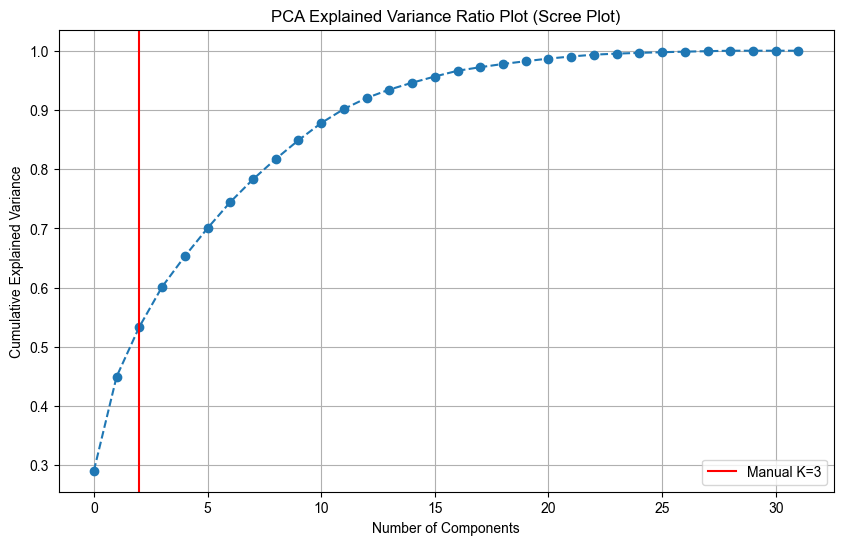


--- Core Discovery: Feature Contribution (Weights) of Principal Components ---


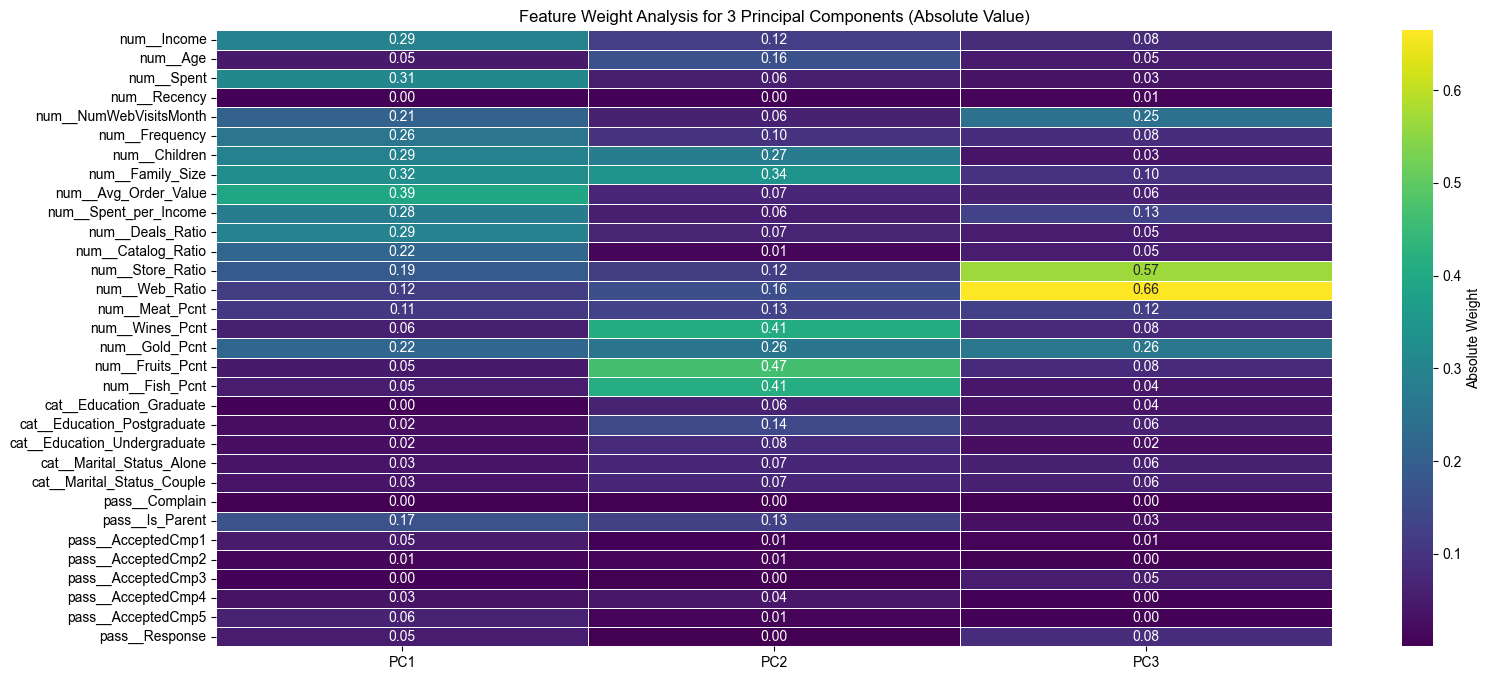


--- Final Decision: Using 3 principal components ---

--- PCA Final Dimensionality Reduction Results ---
Original Dimension: 32
Selected Dimension (N_COMPONENTS_FINAL): 3
Cumulative Variance Retained: 0.5337
Reduced Data Shape: (2210, 3)


In [11]:
# ----------------------------------------------------
# Part III: Feature Scaling and Dimensionality Optimization
# ----------------------------------------------------

# 3.1 Feature Type Definition

# A. Categorical Features (Require One-Hot Encoding)
ONEHOT_FEATURES = ['Education', 'Marital_Status']

# B. Numerical Features (Require RobustScaler)
# Combine all numerical features for scaling
SCALED_FEATURES = [
    'Income', 'Age', 'Spent', 
    'Recency', 
    'NumWebVisitsMonth',
    'Frequency', 'Children', 
    'Family_Size', 'Avg_Order_Value',
    'Spent_per_Income',
    'Deals_Ratio', 'Catalog_Ratio', 
    'Store_Ratio', 'Web_Ratio', 
    'Meat_Pcnt', 'Wines_Pcnt', 'Gold_Pcnt', 'Fruits_Pcnt', 'Fish_Pcnt', 'Sweets_Pcnt' 
    'Total_Accepted_Cmp'
]

# C. Binary (Pass-Through)
PASSTHROUGH_FEATURES = [
    'Complain', 'Is_Parent',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Response'
]

# Filter features to ensure they exist in the dataset
valid_scaled_features = [col for col in SCALED_FEATURES if col in df_processed.columns]
valid_onehot_features = [col for col in ONEHOT_FEATURES if col in df_processed.columns]
valid_passthrough_features = [col for col in PASSTHROUGH_FEATURES if col in df_processed.columns]

# 3.2 Preprocessing Pipeline

numerical_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Define ColumnTransformer: explicitly list all three feature groups
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, valid_scaled_features),
        ('cat', categorical_transformer, valid_onehot_features),
        ('pass', 'passthrough', valid_passthrough_features) # Explicitly pass binary/count features
    ],
    remainder='drop' # Drop all non-specified columns
)

# Prepare input dataset
ALL_INPUT_FEATURES = valid_scaled_features + valid_onehot_features + valid_passthrough_features
X_for_preprocessing = df_processed[ALL_INPUT_FEATURES].copy()


# Apply Preprocessor
df_ready = preprocessor.fit_transform(X_for_preprocessing)

# Get transformed column names
feature_names_transformed = preprocessor.get_feature_names_out()

# Create scaled/encoded DataFrame
df_scaled = pd.DataFrame(df_ready, columns=feature_names_transformed)
print(f"\nDataFrame after Scaling and One-Hot Encoding (df_scaled): {df_scaled.shape}")

# ----------------------------------------------------
# 3.3 Dimensionality Reduction
# ----------------------------------------------------

N_COMPONENTS_MANUAL = 3
print(f"\n--- Manual selection of principal components: N_COMPONENTS = {N_COMPONENTS_MANUAL} ---")
N_COMPONENTS_FINAL = N_COMPONENTS_MANUAL

# 1. Run PCA for Analysis
pca_analysis = PCA(n_components=None)
pca_analysis.fit(df_scaled)

# 2. Plot Explained Variance Ratio
plt.figure(figsize=(10, 6))
cumulative_variance = np.cumsum(pca_analysis.explained_variance_ratio_)
plt.plot(cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Ratio Plot (Scree Plot)')
# Mark manually selected K value
plt.axvline(x=N_COMPONENTS_MANUAL - 1, color='r', linestyle='-',
            label=f'Manual K={N_COMPONENTS_MANUAL}')
plt.legend()
plt.grid(True)
plt.show() # 


# 3. Core Discovery: Analyze Feature Contribution of Top Components
components_df = pd.DataFrame(pca_analysis.components_[:N_COMPONENTS_MANUAL],
                             columns=df_scaled.columns,
                             index=[f'PC{i+1}' for i in range(N_COMPONENTS_MANUAL)])

print("\n--- Core Discovery: Feature Contribution (Weights) of Principal Components ---")

# Use heatmap to visualize feature weights for the components
plt.figure(figsize=(18, 8))
sns.heatmap(
    components_df.T.abs(),
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Absolute Weight'}
)
plt.title(f'Feature Weight Analysis for {N_COMPONENTS_MANUAL} Principal Components (Absolute Value)')
plt.show() # 


# Final Decision: Use the manually selected dimensions for reduction
print(f"\n--- Final Decision: Using {N_COMPONENTS_FINAL} principal components ---")

pca_final = PCA(n_components=N_COMPONENTS_FINAL)
X_pca = pca_final.fit_transform(df_scaled)
explained_variance_retained = pca_final.explained_variance_ratio_.sum()

df_pca = pd.DataFrame(data=X_pca,
                      columns=[f'PC_{i+1}' for i in range(X_pca.shape[1])])

print(f"\n--- PCA Final Dimensionality Reduction Results ---")
print(f"Original Dimension: {df_scaled.shape[1]}")
print(f"Selected Dimension (N_COMPONENTS_FINAL): {N_COMPONENTS_FINAL}")
print(f"Cumulative Variance Retained: {explained_variance_retained:.4f}")
print(f"Reduced Data Shape: {df_pca.shape}")

Calculating Inertia and Silhouette Score for K=2 to K=10...


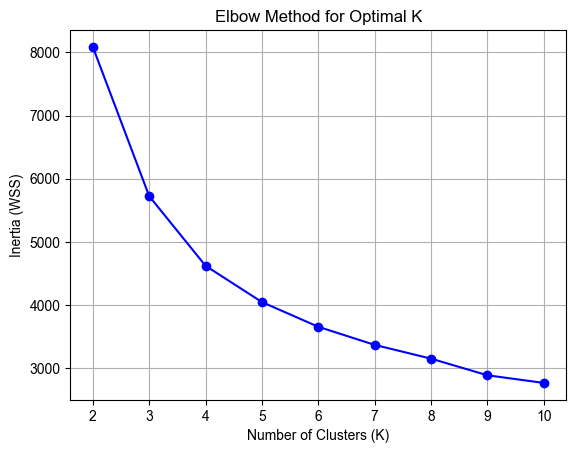

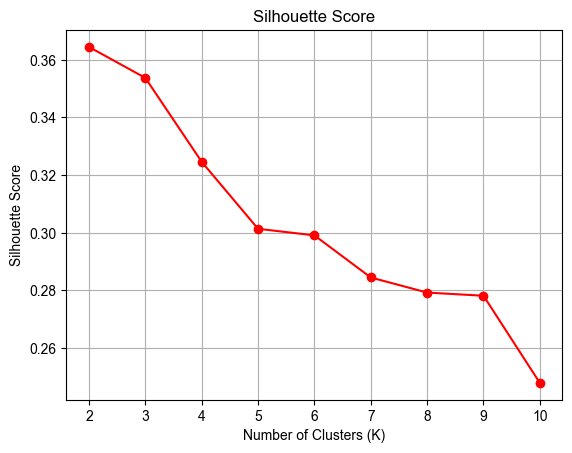

In [12]:
# ----------------------------------------------------
# Part IV: Clustering Analysis
# ----------------------------------------------------

# 4.1 Determine Optimal K using Elbow Method and Silhouette Score

# Define K range
K_RANGE = range(2, 11)
inertia = []        # Within-Cluster Sum of Squares
silhouette_scores = [] # Silhouette Coefficient

print(f"Calculating Inertia and Silhouette Score for K={K_RANGE.start} to K={K_RANGE.stop-1}...")

for k in K_RANGE:
    # Run K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto', max_iter=300)
    kmeans.fit(X_pca)

    # Record WSS (Inertia)
    inertia.append(kmeans.inertia_)

    # Record Silhouette Score
    score = silhouette_score(X_pca, kmeans.labels_)
    silhouette_scores.append(score)

# 4.2 Plotting Evaluation Results

# 1. Elbow Method Plot 
plt.figure()
plt.plot(K_RANGE, inertia, marker='o', color='blue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WSS)')
plt.grid(True)
plt.show()

# 2. Silhouette Score Plot
plt.figure()
plt.plot(K_RANGE, silhouette_scores, marker='o', color='red')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [13]:
# 4.3 Final K Value Decision
K_FINAL = 4

# 4.4 Run Final K-Means Model and Assign Labels
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_pca)

# Assign Cluster Labels and PC columns back to df_processed

# Ensure X_pca is an array/DataFrame for column assignment
X_pca_arr = X_pca if isinstance(X_pca, np.ndarray) else X_pca.values 

df_processed['Cluster_Label'] = cluster_labels
df_processed['PC1'] = X_pca_arr[:, 0]
df_processed['PC2'] = X_pca_arr[:, 1]
df_processed['PC3'] = X_pca_arr[:, 2]  


--- 3D Visualization 1: The dataset after dimensionality reduction ---


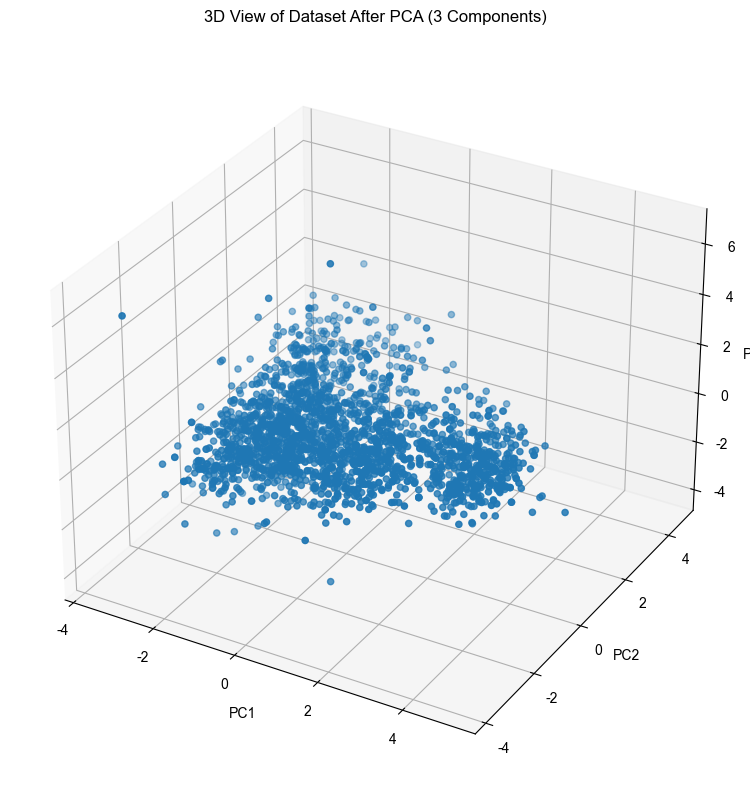


--- 3D Visualization 2: K-Means clustering results ---


C:\Users\C\AppData\Local\Temp\ipykernel_19112\2331636074.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', len(unique_labels))


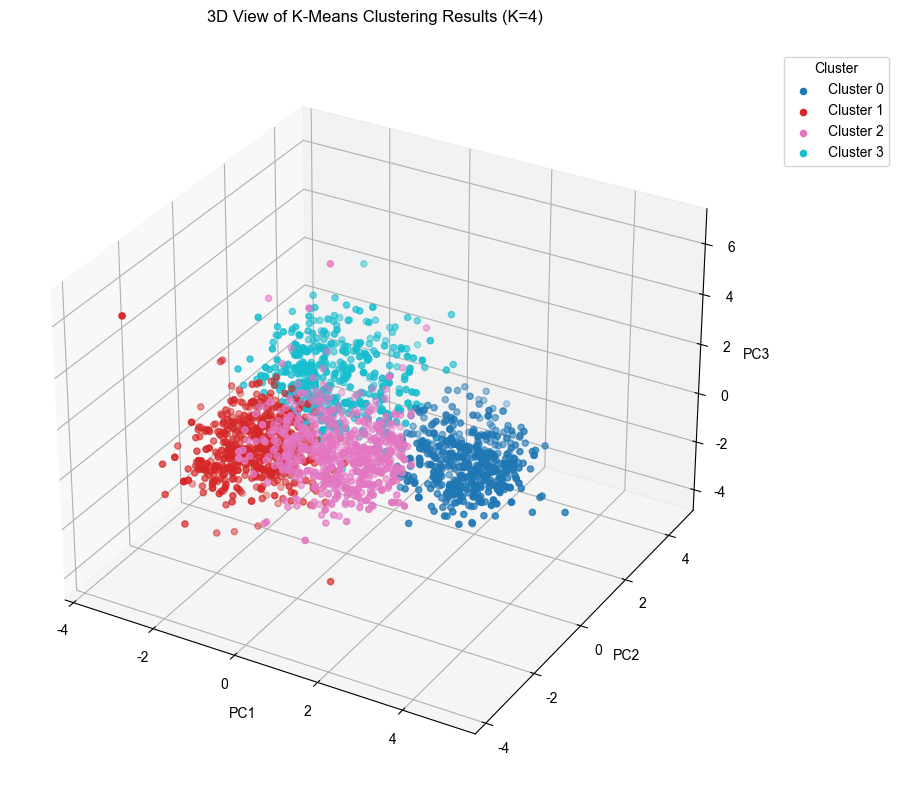

In [14]:
df_plot_data = df_processed.copy()
df_plot_data['Cluster_Label'] = cluster_labels
df_plot_data['Cluster_Label_Str'] = df_plot_data['Cluster_Label'].astype(str)

def plot_static_3d(df, x_col, y_col, z_col, color_col=None, title='3D Scatter Plot', filename='plot.png'):

    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    if color_col:
        unique_labels = sorted(df[color_col].unique(), key=int)
        
        cmap = plt.cm.get_cmap('tab10', len(unique_labels))
        
        for i, label in enumerate(unique_labels):
            subset = df[df[color_col] == label]
            ax.scatter(subset[x_col], subset[y_col], subset[z_col], 
                       label=f'Cluster {label}', color=cmap(i), s=20)
        
        ax.legend(title='Cluster', loc='upper left', bbox_to_anchor=(1.05, 1))
    else:
        ax.scatter(df[x_col], df[y_col], df[z_col], color='#1f77b4', s=20, label='Data Points')

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_zlabel(z_col)
    ax.set_title(title, pad=20)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

K_FINAL = df_plot_data['Cluster_Label'].nunique() 

# --- 3D Visualization 1: The dataset after dimensionality reduction
print("\n--- 3D Visualization 1: The dataset after dimensionality reduction ---")
plot_static_3d(
    df=df_plot_data, 
    x_col='PC1', 
    y_col='PC2', 
    z_col='PC3', 
    color_col=None, 
    title='3D View of Dataset After PCA (3 Components)',
    filename='pca_3d_only.png'
)

# --- 3D Visualization 2: K-Means clustering results ---
print("\n--- 3D Visualization 2: K-Means clustering results ---")
plot_static_3d(
    df=df_plot_data, 
    x_col='PC1', 
    y_col='PC2', 
    z_col='PC3', 
    color_col='Cluster_Label_Str', 
    title=f'3D View of K-Means Clustering Results (K={K_FINAL})',
    filename='clustering_3d.png'
)

客户群体画像

In [15]:
# ----------------------------------------------------
# 5.1 Cluster Mean Analysis of Key Features
# ----------------------------------------------------

# Define core features for cluster profiling
CORE_PROFILE_FEATURES = [
    'Cluster_Label',
    # Spending & Scale
    'Income', 'Spent', 'Spent_per_Income', 'Avg_Order_Value',
    # Demographics
    'Age', 'Family_Size', 'Children',
    # RFM & Campaign Response
    'Recency', 'Frequency', 'Total_Accepted_Cmp',
    # Channel Ratios
    'Deals_Ratio', 'Catalog_Ratio', 'Store_Ratio', 'Web_Ratio',
    # Channel
    'Deals', 'Catalog', 'Store', 'Web',
    # Product
    'Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold',
    # Spending Proportion
    'Wines_Pcnt', 'Fruits_Pcnt', 'Meat_Pcnt',
    'Fish_Pcnt', 'Sweets_Pcnt', 'Gold_Pcnt'
]

# Filter valid features existing in df_processed
valid_profile_features = [col for col in CORE_PROFILE_FEATURES if col in df_processed.columns]

# Calculate cluster size and percentage
cluster_counts = df_processed['Cluster_Label'].value_counts()
total_samples = len(df_processed)
cluster_percentage = (cluster_counts / total_samples) * 100

# Create DataFrame for Count and Percentage, then transpose for merging
cluster_size_df = pd.DataFrame({
    'Count': cluster_counts,
    'Percentage': cluster_percentage
}).T

# Calculate the mean for each cluster
cluster_profile_mean = df_processed[valid_profile_features].groupby('Cluster_Label').mean()

# Select feature columns (excluding Cluster_Label) to calculate the overall mean
data_columns = [col for col in valid_profile_features if col != 'Cluster_Label']
overall_mean = df_processed[data_columns].mean()

# Transpose the cluster means
profile_summary_mean = cluster_profile_mean.T
profile_summary_mean['Overall Mean'] = overall_mean

# Concatenate size info and mean info
profile_summary = pd.concat([cluster_size_df, profile_summary_mean], axis=0)


print("\n--- Cluster Profile Summary ---")
print(profile_summary.to_markdown(floatfmt=".2f"))


--- Cluster Profile Summary ---
|                    |        2 |        1 |        0 |        3 |   Overall Mean |
|:-------------------|---------:|---------:|---------:|---------:|---------------:|
| Count              |   637.00 |   580.00 |   510.00 |   483.00 |         nan    |
| Percentage         |    28.82 |    26.24 |    23.08 |    21.86 |         nan    |
| Income             | 59206.98 | 40497.04 | 76784.00 | 30143.77 |       52001.09 |
| Spent              |   771.65 |   131.65 |  1389.33 |   134.38 |         606.95 |
| Spent_per_Income   |     0.01 |     0.00 |     0.02 |     0.00 |           0.01 |
| Avg_Order_Value    |    43.76 |    15.90 |    74.49 |    15.55 |          37.37 |
| Age                |    49.38 |    47.23 |    47.15 |    39.32 |          46.10 |
| Family_Size        |     2.72 |     3.46 |     1.64 |     2.40 |           2.59 |
| Children           |     1.06 |     1.70 |     0.07 |     0.82 |           0.95 |
| Recency            |    48.71 |    48.67 

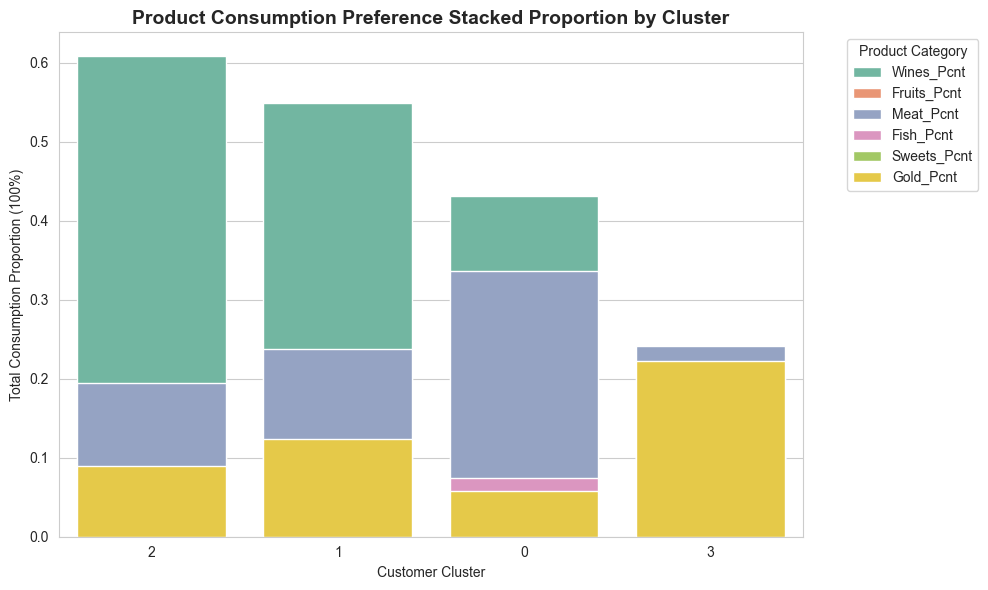

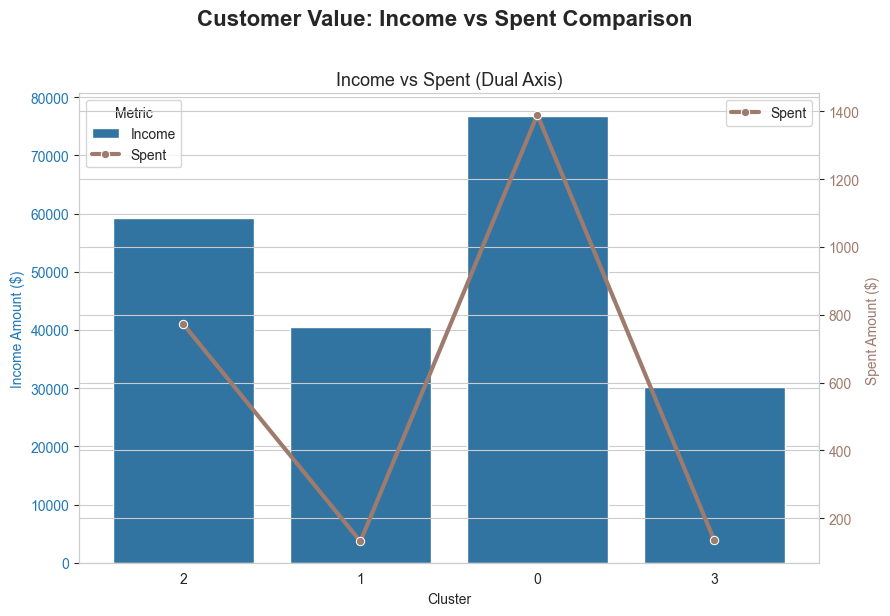

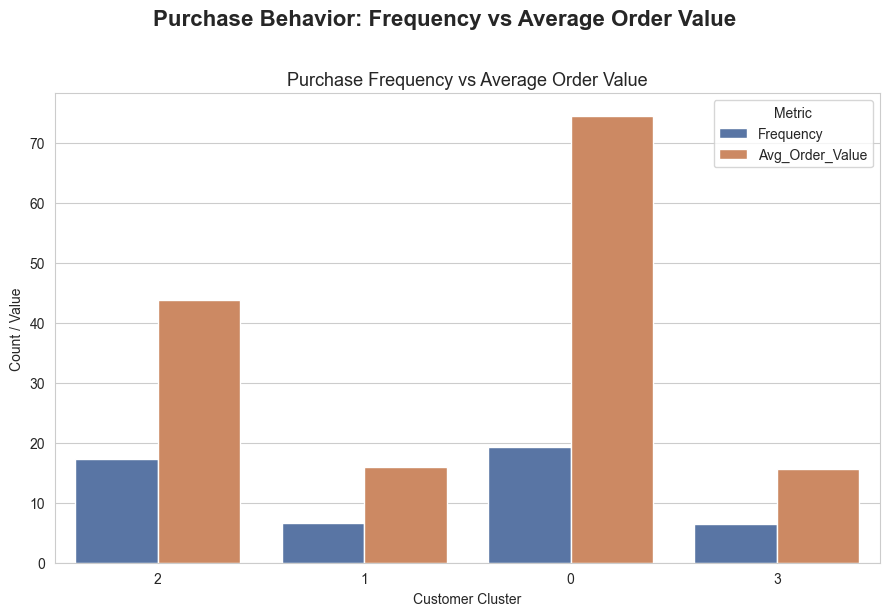

In [16]:
# Extract plotting DataFrame: remove 'Overall Mean' column
profile_df = profile_summary.drop('Overall Mean', axis=1, errors='ignore').T.reset_index(names=['Cluster'])
# Ensure 'Cluster' column is string type
profile_df['Cluster'] = profile_df['Cluster'].astype(str)

sns.set_style("whitegrid")
# Removed Chinese font settings
plt.rcParams['axes.unicode_minus'] = False

PREF_PALETTE = sns.color_palette("Set2", 6) # Plot 1
INCOME_COLOR = '#1F77B4' # Plot 2
SPENT_COLOR = '#9E7B6C' # Plot 2
COUNT_COLOR = '#2CA02C' # Plot 3
METRIC_PALETTE = ['#4C72B0', '#DD8452'] # Plot 4

## =================================================================
## 1. Consumption Preference Stacked Bar Chart
## =================================================================

preference_cols = [col for col in profile_df.columns if col.endswith('_Pcnt')]
preference_df = profile_df[['Cluster'] + preference_cols].set_index('Cluster')

# Reshape data for stacked bar chart
preference_df_stacked = preference_df.stack().reset_index(name='Percentage')
preference_df_stacked.columns = ['Cluster', 'Product', 'Percentage']

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Cluster',
    y='Percentage',
    hue='Product',
    data=preference_df_stacked,
    dodge=False, # Set to False for stacking
    palette=PREF_PALETTE
)
plt.title('Product Consumption Preference Stacked Proportion by Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Total Consumption Proportion (100%)')
plt.xlabel('Customer Cluster')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



## =================================================================
## 2. Customer Value: Income vs Spent (Dual Axis)
## =================================================================

plt.figure(figsize=(9, 6))
plt.suptitle('Customer Value: Income vs Spent Comparison', fontsize=16, fontweight='bold', y=1.02)


# Create primary axis (for Income)
ax1 = plt.subplot(1, 1, 1)

sns.barplot(x='Cluster', y='Income', data=profile_df, color=INCOME_COLOR, label='Income', ax=ax1)
ax1.set_title('Income vs Spent (Dual Axis)', fontsize=13)
ax1.set_ylabel('Income Amount ($)', color=INCOME_COLOR)
ax1.tick_params(axis='y', labelcolor=INCOME_COLOR)
ax1.ticklabel_format(style='plain', axis='y')

# Create secondary axis (for Spent)
ax2 = ax1.twinx()

sns.lineplot(x='Cluster', y='Spent', data=profile_df, color=SPENT_COLOR, marker='o', ax=ax2, linewidth=3, label='Spent')
ax2.set_ylabel('Spent Amount ($) ', color=SPENT_COLOR)
ax2.tick_params(axis='y', labelcolor=SPENT_COLOR)
ax2.ticklabel_format(style='plain', axis='y')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', title='Metric')

plt.tight_layout()
plt.show()

## =================================================================
## 3. Purchase Frequency vs Average Order Value
## =================================================================

plt.figure(figsize=(9, 6))
plt.suptitle('Purchase Behavior: Frequency vs Average Order Value', fontsize=16, fontweight='bold', y=1.02)


# Plot 5: Purchase Frequency vs Average Order Value
melted_df_5 = profile_df.melt(id_vars='Cluster', value_vars=['Frequency', 'Avg_Order_Value'], var_name='Metric', value_name='Value')
sns.barplot(x='Cluster', y='Value', hue='Metric', data=melted_df_5, palette=METRIC_PALETTE)
plt.title('Purchase Frequency vs Average Order Value', fontsize=13)
plt.ylabel('Count / Value')
plt.xlabel('Customer Cluster')
plt.legend(title='Metric', loc='upper right')
plt.tight_layout()
plt.show()

In [17]:
# ----------------------------------------------------
# 5.1 Categorical Feature Cluster Profile Analysis
# ----------------------------------------------------

CATEGORY_COLS_FOR_PROFILE = ['Education', 'Marital_Status']

print("\n--- Cluster Profile Summary: Categorical Feature Distribution (%) ---")

for col in CATEGORY_COLS_FOR_PROFILE:
    # Calculate the proportion (percentage) of each categorical feature value within each cluster
    cluster_counts = (
        df_processed.groupby('Cluster_Label')[col]
        .value_counts(normalize=True)
        .mul(100) # Convert to percentage
        .rename('Percentage')
        .reset_index()
    )

    print(f"\nFeature: {col}")

    # Convert the result to a pivot table format for readability (fill NaN with 0)
    profile_pivot = cluster_counts.pivot(index='Cluster_Label', columns=col, values='Percentage').fillna(0)

    # Calculate overall distribution as a baseline
    overall_perc = df_processed[col].value_counts(normalize=True).mul(100)

    # Print within-cluster percentages
    print(profile_pivot.to_markdown(floatfmt=".1f"))

    # Print overall percentages
    print("\nOverall Distribution:")
    print(overall_perc.to_markdown(floatfmt=".1f"))


--- Cluster Profile Summary: Categorical Feature Distribution (%) ---

Feature: Education
|   Cluster_Label |   Graduate |   Postgraduate |   Undergraduate |
|----------------:|-----------:|---------------:|----------------:|
|               0 |       53.7 |           37.6 |             8.6 |
|               1 |       44.5 |           49.7 |             5.9 |
|               2 |       48.4 |           46.9 |             4.7 |
|               3 |       56.5 |           13.7 |            29.8 |

Overall Distribution:
| Education     |   proportion |
|:--------------|-------------:|
| Graduate      |         50.4 |
| Postgraduate  |         38.2 |
| Undergraduate |         11.4 |

Feature: Marital_Status
|   Cluster_Label |   Alone |   Couple |
|----------------:|--------:|---------:|
|               0 |    43.7 |     56.3 |
|               1 |    24.7 |     75.3 |
|               2 |    33.8 |     66.2 |
|               3 |    41.8 |     58.2 |

Overall Distribution:
| Marital_Status   

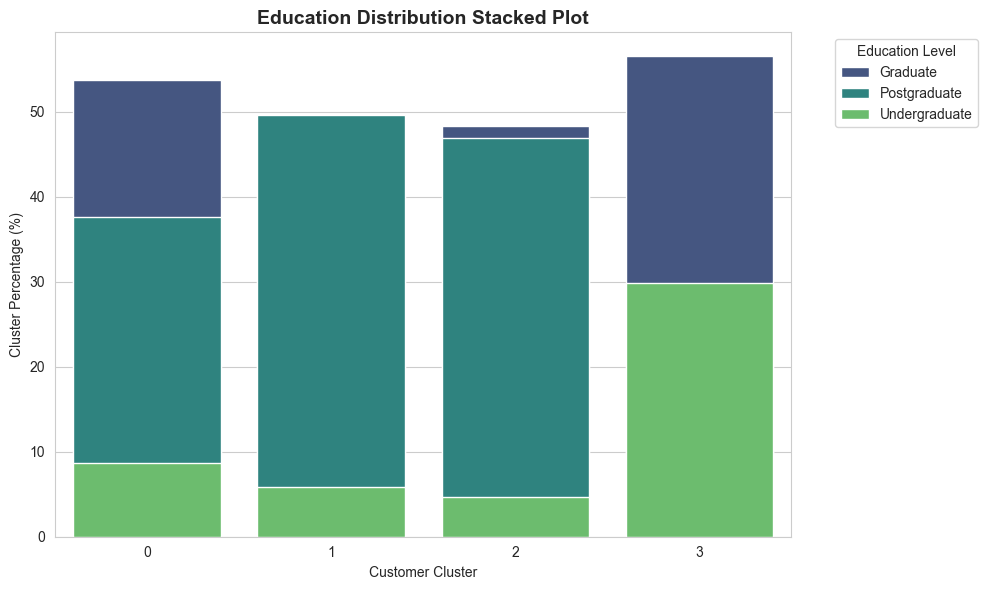

In [18]:
# --- 1. Calculate percentage distribution of Education within each cluster ---
cluster_education_counts = (
    df_processed.groupby('Cluster_Label')['Education']
    .value_counts(normalize=True)
    .mul(100) # Convert to percentage
    .rename('Percentage')
    .reset_index()
)

# Ensure Cluster_Label is string type to prevent sorting issues in plot
cluster_education_counts['Cluster_Label'] = cluster_education_counts['Cluster_Label'].astype(str)

# --- 2. Set plot style ---
sns.set_style("whitegrid")
# Note: Removed Chinese font settings (SimHei)
plt.rcParams['axes.unicode_minus'] = False

# --- 3. Plot Stacked Bar Chart ---
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Cluster_Label',
    y='Percentage',
    hue='Education',
    data=cluster_education_counts,
    dodge=False, # Stack bars
    palette=sns.color_palette("viridis", len(cluster_education_counts['Education'].unique()))
)

plt.title('Education Distribution Stacked Plot', fontsize=14, fontweight='bold')
plt.ylabel('Cluster Percentage (%)')
plt.xlabel('Customer Cluster')
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
# ----------------------------------------------------
# 5.1 Cluster Mean Analysis of Binary/Count Features
# ----------------------------------------------------

# C. Binary/Count Features (Pass-Through)
PASSTHROUGH_FEATURES = [
    'Complain', 'Is_Parent',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Response', 'Total_Accepted_Cmp'
]

# Extract the valid features existing in df_processed
valid_passthrough_features = [col for col in PASSTHROUGH_FEATURES if col in df_processed.columns]

# 1. Calculate the mean for each cluster (Mean represents the average count or acceptance rate)
cluster_profile_binary_mean = df_processed.groupby('Cluster_Label')[valid_passthrough_features].mean()

# 2. Calculate the overall mean for comparison
overall_binary_mean = df_processed[valid_passthrough_features].mean()

# 3. Transpose the cluster means and add the overall mean
profile_summary_binary = cluster_profile_binary_mean.T
profile_summary_binary['Overall Mean'] = overall_binary_mean

print("\n--- Cluster Profile Summary: Binary/Count Features (Mean) ---")
    
# Format the result as a Markdown table
print(profile_summary_binary.to_markdown(floatfmt=".3f"))


--- Cluster Profile Summary: Binary/Count Features (Mean) ---
|                    |     0 |     1 |     2 |     3 |   Overall Mean |
|:-------------------|------:|------:|------:|------:|---------------:|
| Complain           | 0.006 | 0.010 | 0.008 | 0.012 |          0.009 |
| Is_Parent          | 0.075 | 1.000 | 0.940 | 0.749 |          0.714 |
| AcceptedCmp1       | 0.218 | 0.003 | 0.046 | 0.000 |          0.064 |
| AcceptedCmp2       | 0.035 | 0.003 | 0.016 | 0.000 |          0.014 |
| AcceptedCmp3       | 0.078 | 0.059 | 0.088 | 0.068 |          0.074 |
| AcceptedCmp4       | 0.127 | 0.024 | 0.133 | 0.000 |          0.074 |
| AcceptedCmp5       | 0.269 | 0.000 | 0.038 | 0.000 |          0.073 |
| Response           | 0.304 | 0.083 | 0.126 | 0.104 |          0.151 |
| Total_Accepted_Cmp | 0.727 | 0.090 | 0.320 | 0.068 |          0.299 |


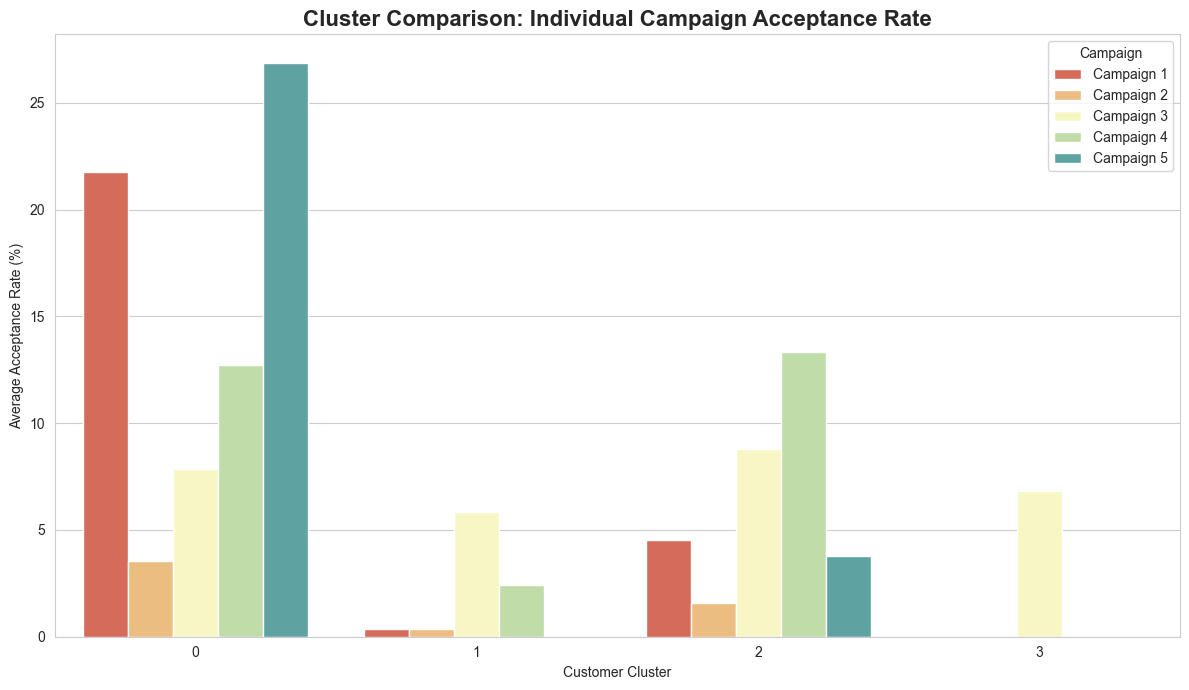

In [20]:
CMP_PALETTE = sns.color_palette("Spectral", 5)
campaign_metrics = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
cmp_df = profile_summary_binary.loc[campaign_metrics].drop(columns=['Overall Mean'])

# Transpose DataFrame and melt for sns.barplot
cmp_df_T = cmp_df.T.reset_index(names=['Cluster'])

# Melt data: 5 campaigns become the 'Campaign' variable
melted_cmp_df = cmp_df_T.melt(
    id_vars='Cluster',
    var_name='Campaign',
    value_name='Acceptance_Rate'
)

# Convert acceptance rate to percentage format
melted_cmp_df['Acceptance_Rate_Pcnt'] = melted_cmp_df['Acceptance_Rate'] * 100

# 2. Draw Grouped Bar Chart
plt.figure(figsize=(12, 7))


sns.barplot(
    data=melted_cmp_df,
    x='Cluster',
    y='Acceptance_Rate_Pcnt',
    hue='Campaign',
    palette=CMP_PALETTE
)

# 3. Enhance Chart Aesthetics
plt.title('Cluster Comparison: Individual Campaign Acceptance Rate', fontsize=16, fontweight='bold')
plt.ylabel('Average Acceptance Rate (%)')
plt.xlabel('Customer Cluster')

# Adjust legend labels
new_legend_labels = {
    'AcceptedCmp1': 'Campaign 1',
    'AcceptedCmp2': 'Campaign 2',
    'AcceptedCmp3': 'Campaign 3',
    'AcceptedCmp4': 'Campaign 4',
    'AcceptedCmp5': 'Campaign 5',
}
L = plt.legend(title='Campaign', loc='upper right')
for text in L.get_texts():
    if text.get_text() in new_legend_labels:
        text.set_text(new_legend_labels[text.get_text()])

plt.tight_layout()
plt.show()

In [21]:
FEATURE_GROUPS = {
    "Value & Demographics": ['Income', 'Spent', 'Family_Size', 'Total_Accepted_Cmp'],
    "Product Preference": ['Wines_Pcnt', 'Meat_Pcnt', 'Fish_Pcnt', 
                           'Fruits_Pcnt', 'Sweets_Pcnt', 'Gold_Pcnt']
}

In [22]:
# Plotting function
def plot_radar_group(ax, data_df, title, z_ticks, offset, show_legend=False):
    raw_categories = data_df.columns.tolist()
    
    categories = [
        label.replace('Mnt', '')
             .replace('Products', '')
             .replace('_Pcnt', ' ') 
             .replace('_', ' ') 
             .strip()
        for label in raw_categories
    ]
    
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # Plot Z=0 baseline
    full_angles = np.linspace(0, 2 * pi, 100, endpoint=True)
    r_values = np.full_like(full_angles, offset) 
    ax.plot(
        full_angles, 
        r_values, 
        color='black', 
        linestyle='--', 
        linewidth=2, 
        alpha=0.8, 
        label='Overall Mean (Z=0)',
        zorder=1
    )
    
    # Plot each cluster profile
    for i in range(len(data_df)):
        values = data_df.iloc[[i]].values.flatten().tolist()
        values += values[:1]
        cluster_label = data_df.index[i]
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster_label}', alpha=0.8)

    # Set X-axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)

    # Set Y-axis labels (Z-Score)
    ax.set_yticks(z_ticks)
    ax.set_yticklabels([f"{z:.1f}" for z in (z_ticks - offset)], color="grey", size=8)

    # Set Y-axis range and title
    ax.set_ylim(0, data_df.max().max() + 0.5)
    ax.set_title(title, size=12, y=1.2)
    ax.tick_params(axis='x', pad=10)
    
    if show_legend:
        # Display legend only when needed
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(data_df.index), title="Cluster Label")


# --- 3. Data Preparation and Calculation ---

# Extract all relevant features
ALL_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]
# Ensure profile_summary exists and has the correct table structure
cluster_means_all = profile_summary.T[ALL_FEATURES].drop(index='Overall Mean', errors='ignore')

# Perform Z-Score standardization on all data
scaler_all = StandardScaler()
standardized_data_all = scaler_all.fit_transform(cluster_means_all)
standardized_df_all = pd.DataFrame(standardized_data_all, columns=ALL_FEATURES, index=cluster_means_all.index)


# Determine global offset and tick positions (Global standardization)
min_z_score_all = standardized_df_all.min().min()
OFFSET_ALL = abs(min_z_score_all) + 1.0
offset_df_all = standardized_df_all + OFFSET_ALL

# Determine Y-axis ticks (Z-Score)
max_offset_val_all = offset_df_all.max().max()
z_ticks_all = np.arange(np.floor(min_z_score_all), np.ceil(max_offset_val_all - OFFSET_ALL) + 1, 1)
tick_positions_all = z_ticks_all + OFFSET_ALL
tick_positions_all = tick_positions_all[tick_positions_all >= 0]

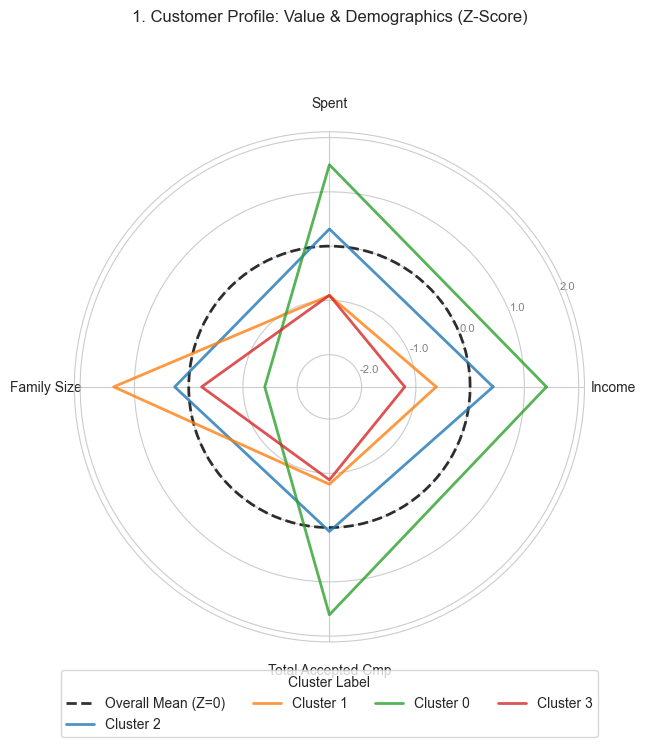

In [23]:
# Spent and Family Size Radar Chart
fig, ax0 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

data_0 = offset_df_all[FEATURE_GROUPS["Value & Demographics"]]

plot_radar_group(
    ax0, 
    data_0, 
    "1. Customer Profile: Value & Demographics (Z-Score)", 
    tick_positions_all, 
    OFFSET_ALL,
    show_legend=True
)

plt.tight_layout()
plt.show()

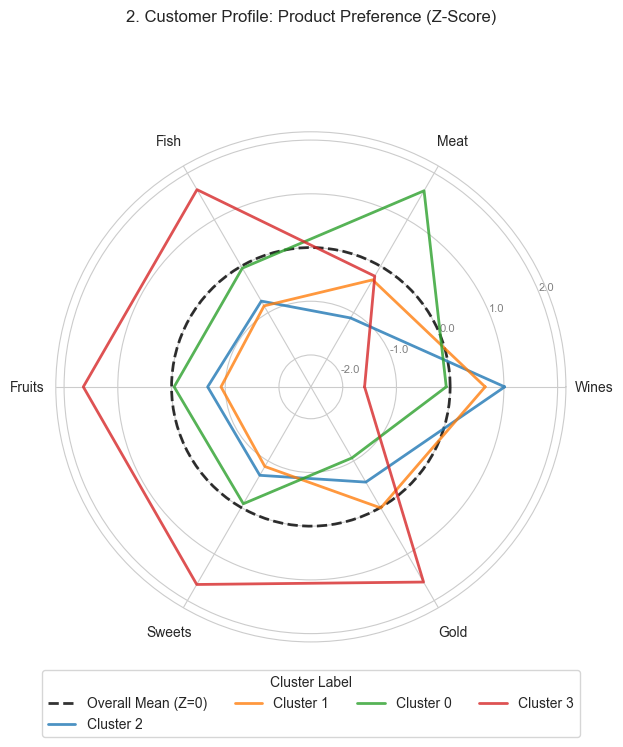

In [24]:
# Product Preference Radar Chart

fig, ax1 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

data_1 = offset_df_all[FEATURE_GROUPS["Product Preference"]]

plot_radar_group(
    ax1, 
    data_1, 
    "2. Customer Profile: Product Preference (Z-Score)", 
    tick_positions_all, 
    OFFSET_ALL,
    show_legend=True
)

plt.tight_layout()
plt.show()

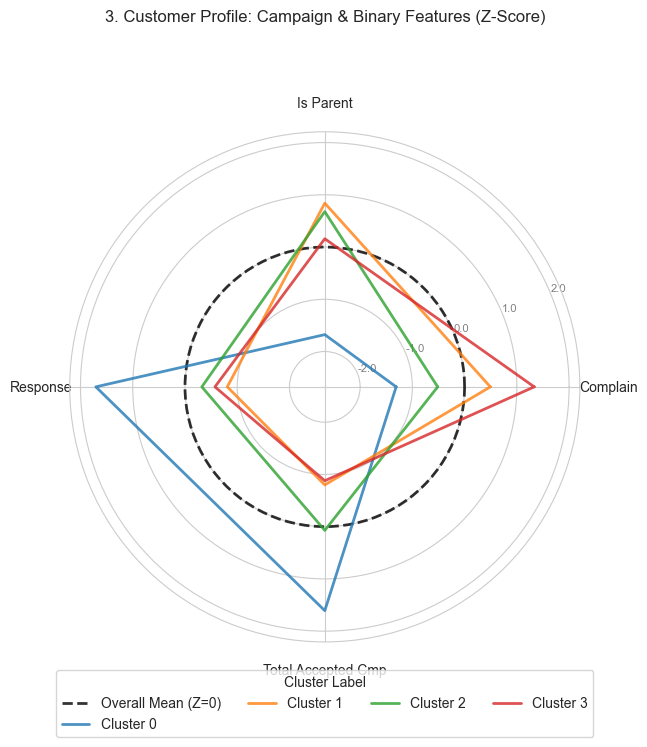

In [25]:
cluster_means_binary_filtered = profile_summary_binary.T.drop(index='Overall Mean', errors='ignore').drop(columns=['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5'], errors='ignore')
binary_features_filtered = cluster_means_binary_filtered.columns.tolist()

# Apply Z-Score Standardization
scaler_binary = StandardScaler()
standardized_data_binary_filtered = scaler_binary.fit_transform(cluster_means_binary_filtered)
standardized_df_binary_filtered = pd.DataFrame(
    standardized_data_binary_filtered,
    columns=binary_features_filtered,
    index=cluster_means_binary_filtered.index
)

# Calculate Offset for Radar Plot (to ensure all values are positive)
min_z_score_binary_filtered = standardized_df_binary_filtered.min().min()
OFFSET_BINARY_FILTERED = abs(min_z_score_binary_filtered) + 1.0
offset_df_binary_filtered = standardized_df_binary_filtered + OFFSET_BINARY_FILTERED

# Determine Y-axis Ticks (Z-Score)
max_offset_val_binary_filtered = offset_df_binary_filtered.max().max()
z_ticks_binary_filtered = np.arange(np.floor(min_z_score_binary_filtered), np.ceil(max_offset_val_binary_filtered - OFFSET_BINARY_FILTERED) + 1, 1)
tick_positions_binary_filtered = z_ticks_binary_filtered + OFFSET_BINARY_FILTERED
tick_positions_binary_filtered = tick_positions_binary_filtered[tick_positions_binary_filtered >= 0]
# 5. Plot Radar Chart
fig, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))


data_2 = offset_df_binary_filtered

plot_radar_group(
    ax2,
    data_2,
    "3. Customer Profile: Campaign & Binary Features (Z-Score)",
    tick_positions_binary_filtered,
    OFFSET_BINARY_FILTERED,
    show_legend=True
)

plt.tight_layout()
plt.show()

### 👥 Customer Segmentation Report: In-Depth K-Means Cluster Analysis

This report analyzes the four distinct customer segments based on the latest K-Means clustering results. The profiles focus on key differentiators such as financial standing, spending habits, family structure, and marketing campaign responsiveness.

---

## Detailed Customer Segment Profiles

### 🥇 Cluster 0: The Elite High-Value Gourmets

**Size:** 23.08%

Cluster 0 is the undisputed **core value segment** of the customer base. This group is defined by the **highest average income (\$76,784)** and the **highest total spending (\$1,389)**, indicating exceptional purchasing power. They primarily consist of **small households (Family Size 1.64, Children 0.07)**, typical of high-net-worth singles or DINK (Dual Income, No Kids) couples. Their buying behavior is highly active and focused on **high-value transactions (Avg\_Order\_Value \$74.49)**.

In terms of preferences, they show a strong inclination for **Meat products (Meat\_Pcnt 34%)**, making them the prime target for gourmet offerings. Their shopping channel preference is unique, with the highest use of **Catalog shopping (Catalog\_Ratio 31%)**. Crucially, they are the **most receptive to marketing campaigns (Total\_Accepted\_Cmp 0.73)**, particularly **AcceptedCmp1 and AcceptedCmp5**, suggesting high engagement with exclusive, high-tier promotions.

### 🍷 Cluster 2: The Active Middle-Class Wine Lovers

**Size:** **28.82% (Largest Segment)**

Cluster 2 represents the **largest segment**, characterized by **medium-high income (\$59,207)** and **high spending (\$771.65)**. Their defining characteristic is their role as the **primary wine consumer**, dedicating a massive **61% of their total expenditure to Wines (Wines\_Pcnt 61%)**. They typically represent **families with children (Children 1.06)** and are slightly older (Age 49.38).

This segment exhibits high purchasing frequency (17.21) and utilizes a balanced mix of channels, favoring **Web (Web\_Ratio 38%) and Store shopping**. They also rely on the **Catalog (Catalog\_Ratio 19%)** more than average. Their marketing campaign response rate (0.32) is slightly above the overall mean, positioning them as stable customers whose value can be further enhanced through targeted wine promotions, subscription services, and family-oriented offers.

### 👨‍👩‍👧‍👦 Cluster 1: The Budget-Conscious Large Families

**Size:** 26.24%

Cluster 1 is defined by **low income (\$40,497)** and **very low spending (\$131.65)**, combined with the **largest family size (Family Size 3.46) and the most children (Children 1.70)**. This demographic profile points to significant financial constraints and extreme price sensitivity. Their average order value is the second lowest, at only **\$15.90**.

Their consumption is almost entirely price-driven, evidenced by the **highest Deals Purchase Ratio (Deals\_Ratio 39%)** and low overall purchasing frequency (6.65). They heavily prefer **in-store shopping (Store\_Ratio 59%)** likely to leverage local and timely discounts. Critically, their **marketing campaign response is negligible (Total\_Accepted\_Cmp 0.09)**, indicating that standard advertising is ineffective. Strategies must focus exclusively on deep, utilitarian discounts and bulk-purchase incentives.

### 🧍 Cluster 3: The Lowest Income Independent Spenders

**Size:** 21.86%

Cluster 3 is the group with the **lowest income (\$30,144)** and is the **youngest (Age 39.32)** on average. They are low spenders (\$134.38) with low frequency (6.51). Their most distinctive spending habit is the **highest proportion of expenditure on Gold/Promotional items (Gold\_Pcnt 22%)**. This suggests a strong pursuit of value, perhaps through clearance items, or a preference for small, easily afforded luxury items.

Despite low overall spending, they show a relatively high proportional preference for **Fish (Fish\_Pcnt 15%) and Fruits (Fruits\_Pcnt 11%)**. This segment is the highest in terms of non-postgraduate education (Undergraduate 29.8%). They are also highly dependent on **discounts (Deals\_Ratio 31%)** and have the lowest marketing response rate (0.07), making them challenging to engage through conventional campaigns. Targeted efforts should focus on low-cost, high-value small items via mobile/web channels.

---

## 📝 Summary: Cluster Portrait Table

| Cluster ID | **Core Customer Profile** | **Primary Driver** | **Spending Contribution** | **Key Preference** |
| :---: | :--- | :--- | :--- | :--- |
| **0** | **Elite High-Value** (Highest Income/Spending, Small Household). | High quality, High AOV, Campaign Responsiveness. | **Highest** | Meat, Catalog Shopping. |
| **2** | **Active Wine Lover** (Largest size, Mid-High Income, Family). | Wine, High Frequency, Web/Store Shopping. | **High** | Wine, Web, Store. |
| **1** | **Budget-Sensitive Family** (Lowest Spending, Largest Household, Lowest AOV). | Discounts, Family Necessity, Store Shopping. | **Lowest** | Discounts, Store, Bulk Deals. |
| **3** | **Lowest Income Independent** (Youngest, Lowest Income, Single/Small). | Promotional Items, Budget Focus. | **Low** | Gold/Promotions, Fish, Store. |求性价比或促销品。 | 促销品、个人独特偏好。 | **低** | 黄金/促销品、鱼类、门店。 |